# 自行车共享数据分析

## 问题定义

- 哪个季节的自行车租赁数量最高？
- 每个月和每年的自行车租赁模式如何？
- 特定日期的自行车租赁模式如何？


## 准备库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

## 数据处理

### 数据收集

In [2]:
# 加载每日数据
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# 加载每小时数据
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### 数据评估

#### 评估 day_df

In [4]:
# 查看 day_df 数据信息
day_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


In [5]:
# 检查 day_df 缺失值
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
# 查看 day_df 数据重复数量
print("重复数量: ", day_df.duplicated().sum())

重复数量:  0


In [7]:
# 查看 day_df 列的统计信息
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### 评估 hour_df

In [8]:
# 查看 hour_df 数据信息
hour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [9]:
#  检查 hour_df 缺失值
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
# 查看 hour_df 数据重复数量
print("重复数量: ", hour_df.duplicated().sum())


重复数量:  0


In [11]:
# 查看 hour_df 列的统计信息
hour_df.describe()


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### 3. 清洗数据

#### 修改数据类型

In [12]:
# 将 "dteday" 列的数据类型改为 datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [13]:
# 查看 day_df 数据信息
day_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[us]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[us](1), float64(4), int

In [14]:
# 查看 hour_df 数据信息
hour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

#### 修改列名

In [15]:
# 将列 'dteday', 'yr', 'mnth', 'hr', 'temp', 'hum', 'cnt' 重命名
def rename_columns(dataframe, column_mapping):
    for old_col, new_col in column_mapping.items():
        dataframe.rename(columns={old_col: new_col}, inplace=True)

column_day = {'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'temp': 'temperature', 'hum': 'humidity', 'cnt': 'total'}
column_hour = {'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'hr': 'hour', 'temp': 'temperature', 'hum': 'humidity', 'cnt': 'total'}

rename_columns(day_df, column_day)
rename_columns(hour_df, column_hour)

#### 修改季节分类的名称

In [16]:
season_mapping = {1: '春季', 2: '夏季', 3: '秋季', 4: '冬季'}
day_df['season'] = day_df['season'].replace(season_mapping)
hour_df['season'] = hour_df['season'].replace(season_mapping)

#### 修改月份分类的名称

In [17]:
day_df['month'] = day_df['month'].apply(lambda x: calendar.month_name[x])
hour_df['month'] = hour_df['month'].apply(lambda x: calendar.month_name[x])

#### 修改年份类别名称

In [18]:
year_mapping = {0: '2011年', 1: '2012年'}
day_df['year'] = day_df['year'].replace(year_mapping)
hour_df['year'] = hour_df['year'].replace(year_mapping)

#### 修改星期分类的名称

In [19]:
weekday_mapping = {0: '星期日', 1: '星期一', 2: '星期二', 3: '星期三', 4: '星期四', 5: '星期五', 6: '星期六'}
day_df['weekday'] = day_df['weekday'].replace(weekday_mapping)
hour_df['weekday'] = hour_df['weekday'].replace(weekday_mapping)

In [20]:
# 查看day_df的前几行
day_df.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,atemp,humidity,windspeed,casual,registered,total
0,1,2011-01-01,春季,2011年,January,0,星期六,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,春季,2011年,January,0,星期日,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,春季,2011年,January,0,星期一,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,春季,2011年,January,0,星期二,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,春季,2011年,January,0,星期三,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [21]:
# 查看hour_df的前几行数据
hour_df.head()

,instant,date,season,year,month,hour,holiday,weekday,workingday,weathersit,temperature,atemp,humidity,windspeed,casual,registered,total
0,1,2011-01-01,春季,2011年,January,0,0,星期六,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,春季,2011年,January,1,0,星期六,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,春季,2011年,January,2,0,星期六,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,春季,2011年,January,3,0,星期六,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,春季,2011年,January,4,0,星期六,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 探索性数据分析（EDA）

#### 根据季节的自行车使用统计

In [22]:
day_df.groupby(by="season").agg({
    "casual": ["max", "min", "mean", "sum"],
    "registered": ["max", "min", "mean", "sum"],
    "total": ["max", "min", "mean", "sum"]
})

casual                           registered                            \
          max  min         mean     sum        max  min         mean     sum   
season                                                                         
冬季       3031    2   729.112360  129782       6946   20  3999.050562  711831   
夏季       3410  120  1106.097826  203522       6456  674  3886.233696  715067   
春季       3155    9   334.928177   60622       5315  416  2269.204420  410726   
秋季       3160  118  1202.611702  226091       6917  889  4441.691489  835038   

       total                              
         max   min         mean      sum  
season                                    
冬季      8555    22  4728.162921   841613  
夏季      8362   795  4992.331522   918589  
春季      7836   431  2604.132597   471348  
秋季      8714  1115  5644.303191  1061129

#### 根据月份和年份的自行车使用统计

In [23]:
month_order = {month: i for i, month in enumerate(calendar.month_name[1:], start=1)}
day_df['month'] = pd.Categorical(day_df['month'], categories=sorted(month_order, key=month_order.get))

day_df.groupby(by=["year", "month"], observed=False).agg({
    "casual": ["max", "min", "mean", "sum"],
    "registered": ["max", "min", "mean", "sum"],
    "total": ["max", "min", "mean", "sum"]
})

casual                          registered                     \
                   max  min         mean    sum        max   min         mean   
year  month                                                                     
2011年 January      331    9    99.129032   3073       1844   416  1132.774194   
      February     694   47   222.928571   6242       2348   905  1499.035714   
      March       1424   46   413.741935  12826       2355   491  1652.225806   
      April       1965  121   744.866667  22346       3722   674  2417.466667   
      May         2355  255  1001.612903  31050       4238  2213  3379.709677   
      June        1920  513  1020.400000  30612       4488  2993  3763.333333   
      July        3065  562  1175.870968  36452       4220  2298  3383.516129   
      August      1914  226   930.387097  28842       4614   889  3479.000000   
      September   2521  118   884.833333  26545       4372  1689  3362.433333   
      October     2397   57   813.612903  25222       4267   570  3170.612903   
      November    1275   69   519.800000  15594       3891   935  2885.766667   
      December     706   50   272.516129   8448       3672   451  2544.354839   
2012年 January     1070   67   289.322581   8969       4185  1234  2831.451613   
      February    1435   65   300.724138   8721       4546  1456  3255.724138   
      March       3155  203  1019.935484  31618       5893  2339  4298.612903   
      April       3252  120  1281.866667  38456       5950   907  4525.600000   
      May         3410  342  1426.935484  44235       6433  2501  4891.290323   
      June        2963  477  1443.133333  43294       6456  3594  5317.866667   
      July        2562  747  1345.322581  41705       6790  3195  5222.645161   
      August      2827  935  1393.451613  43197       6541  3341  5526.000000   
      September   3160  371  1459.266667  43778       6946  3197  5826.500000   
      October     3031    2  1114.129032  34538       6911    20  5300.096774   
      November    2290  123   700.300000  21009       5520  1470  4388.500000   
      December    1153    9   427.258065  13245       6055   432  3563.483871   

                        total                             
                    sum   max   min         mean     sum  
year  month                                               
2011年 January     35116  1985   431  1231.903226   38189  
      February    41973  2927  1005  1721.964286   48215  
      March       51219  3239   605  2065.967742   64045  
      April       72524  5312   795  3162.333333   94870  
      May        104771  5805  2633  4381.322581  135821  
      June       112900  5515  3767  4783.733333  143512  
      July       104889  6043  3285  4559.387097  141341  
      August     107849  5895  1115  4409.387097  136691  
      September  100873  5423  1842  4247.266667  127418  
      October     98289  5511   627  3984.225806  123511  
      November    86573  4486  1495  3405.566667  102167  
      December    78875  3940   705  2816.870968   87323  
2012年 January     87775  4521  1301  3120.774194   96744  
      February    94416  5062  1529  3556.448276  103137  
      March      133257  8362  3194  5318.548387  164875  
      April      135768  7460  1027  5807.466667  174224  
      May        151630  8294  2843  6318.225806  195865  
      June       159536  8120  4127  6761.000000  202830  
      July       161902  8173  4459  6567.967742  203607  
      August     171306  7865  4549  6919.451613  214503  
      September  174795  8714  4073  7285.766667  218573  
      October    164303  8156    22  6414.225806  198841  
      November   131655  6852  2277  5088.800000  152664  
      December   110468  6606   441  3990.741935  123713

#### 每个节假日的自行车使用量

In [24]:
hour_df[(hour_df["holiday"] == 1) | (hour_df["workingday"] == 0)].groupby(by=["weekday"], observed=False).agg({"total": ["sum"]})

,total
,sum
weekday,
星期一,59605
星期三,7403
星期二,1013
星期五,6494
星期六,477807
星期四,3920
星期日,444027


#### 每个工作日的自行车使用量

In [25]:
hour_df[(hour_df["holiday"] == 0) & (hour_df["workingday"] == 1)].groupby(by=["weekday"], observed=False).agg({"total": ["sum"]})

,total
,sum
weekday,
星期一,395898
星期三,465645
星期二,468096
星期五,481296
星期四,481475


## 数据可视化

### 问题1：在哪个季节自行车使用量最高？

c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31199 (\N{CJK UNIFIED IDEOGRAPH-79DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36161 (\N{CJK UNIFIED IDEOGRAPH-8D41}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\U

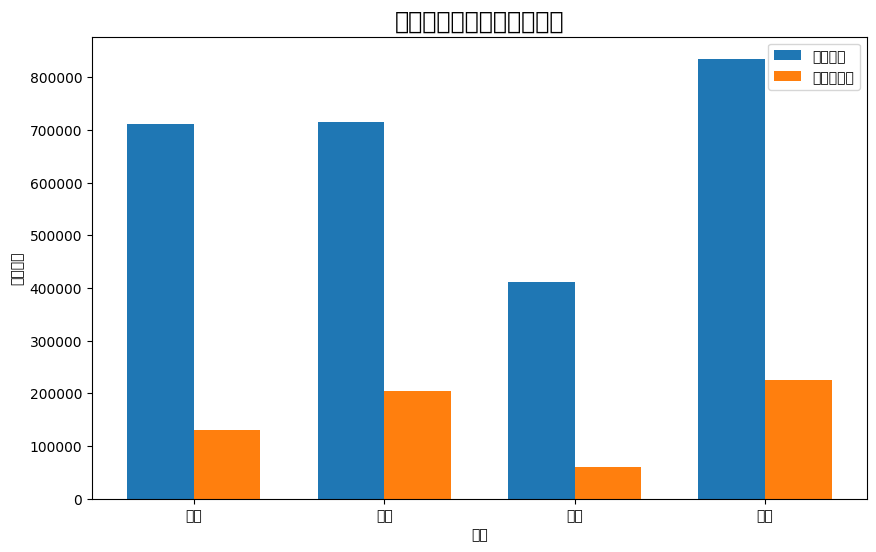

In [26]:
plot_season = day_df.groupby('season')[['registered', 'casual']].sum().reset_index()

plt.figure(figsize=(10, 6))

bar_width = 0.35
bar_positions1 = range(len(plot_season['season']))
bar_positions2 = [pos + bar_width for pos in bar_positions1]

plt.bar(bar_positions1, plot_season['registered'], width=bar_width, label='注册用户', color='tab:blue')
plt.bar(bar_positions2, plot_season['casual'], width=bar_width, label='非注册用户', color='tab:orange')

plt.xlabel('季节')
plt.ylabel('租赁总数')
plt.title('自行车租赁总数按季节分布', fontsize = 17)
plt.xticks([pos + bar_width/2 for pos in bar_positions1], plot_season['season'])
plt.legend()
plt.show()

### 问题2：在每个月和每年的自行车租赁模式如何变化？

C:\Users\30773\AppData\Local\Temp\ipykernel_35168\3022936498.py:23: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30773\AppData\Local\Temp\ipykernel_35168\3022936498.py:23: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30773\AppData\Local\Temp\ipykernel_35168\3022936498.py:23: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30773\AppData\Local\Temp\ipykernel_35168\3022936498.py:23: UserWarning: Glyph 31199 (\N{CJK UNIFIED IDEOGRAPH-79DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30773\AppData\Local\Temp\ipykernel_35168\3022936498.py:23: UserWarning: Glyph 36161 (\N{CJK UNIFIED IDEOGRAPH-8D41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\30773\AppData\Local\Temp\ipykernel_35168\3022936498.py:23: UserWarning: Glyph 25968 (\

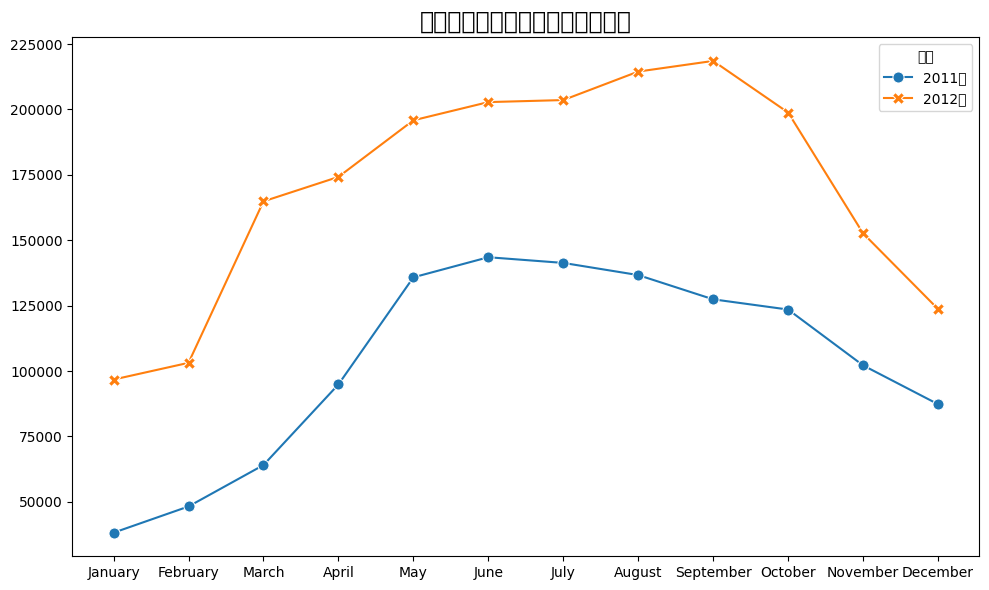

In [27]:
plt.figure(figsize=(10, 6))

plot_ym = day_df.groupby(by=["month", "year"], observed=False).agg({
    "total": "sum"
}).reset_index()

sns.lineplot(
    data=plot_ym,
    x="month",
    y="total",
    hue="year",
    style="year",  
    markers=True,
    markersize=8,  
    dashes=False,  
)

plt.grid(False)
plt.title("自行车租赁数量按月份和年份分布", fontsize = 17)
plt.xlabel(None)
plt.ylabel(None)
plt.legend(title="年份", loc="upper right")
plt.tight_layout()

plt.show()


### 问题3：在特定日期的自行车租赁模式如何变化？

c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\30773\Pycha

SyntaxError: keyword argument repeated: fontsize (2231108837.py, line 10)

c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\c

<Figure size 3000x1000 with 0 Axes>

c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\30773\PycharmProjects\PythonProject1\bike-sharing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\U

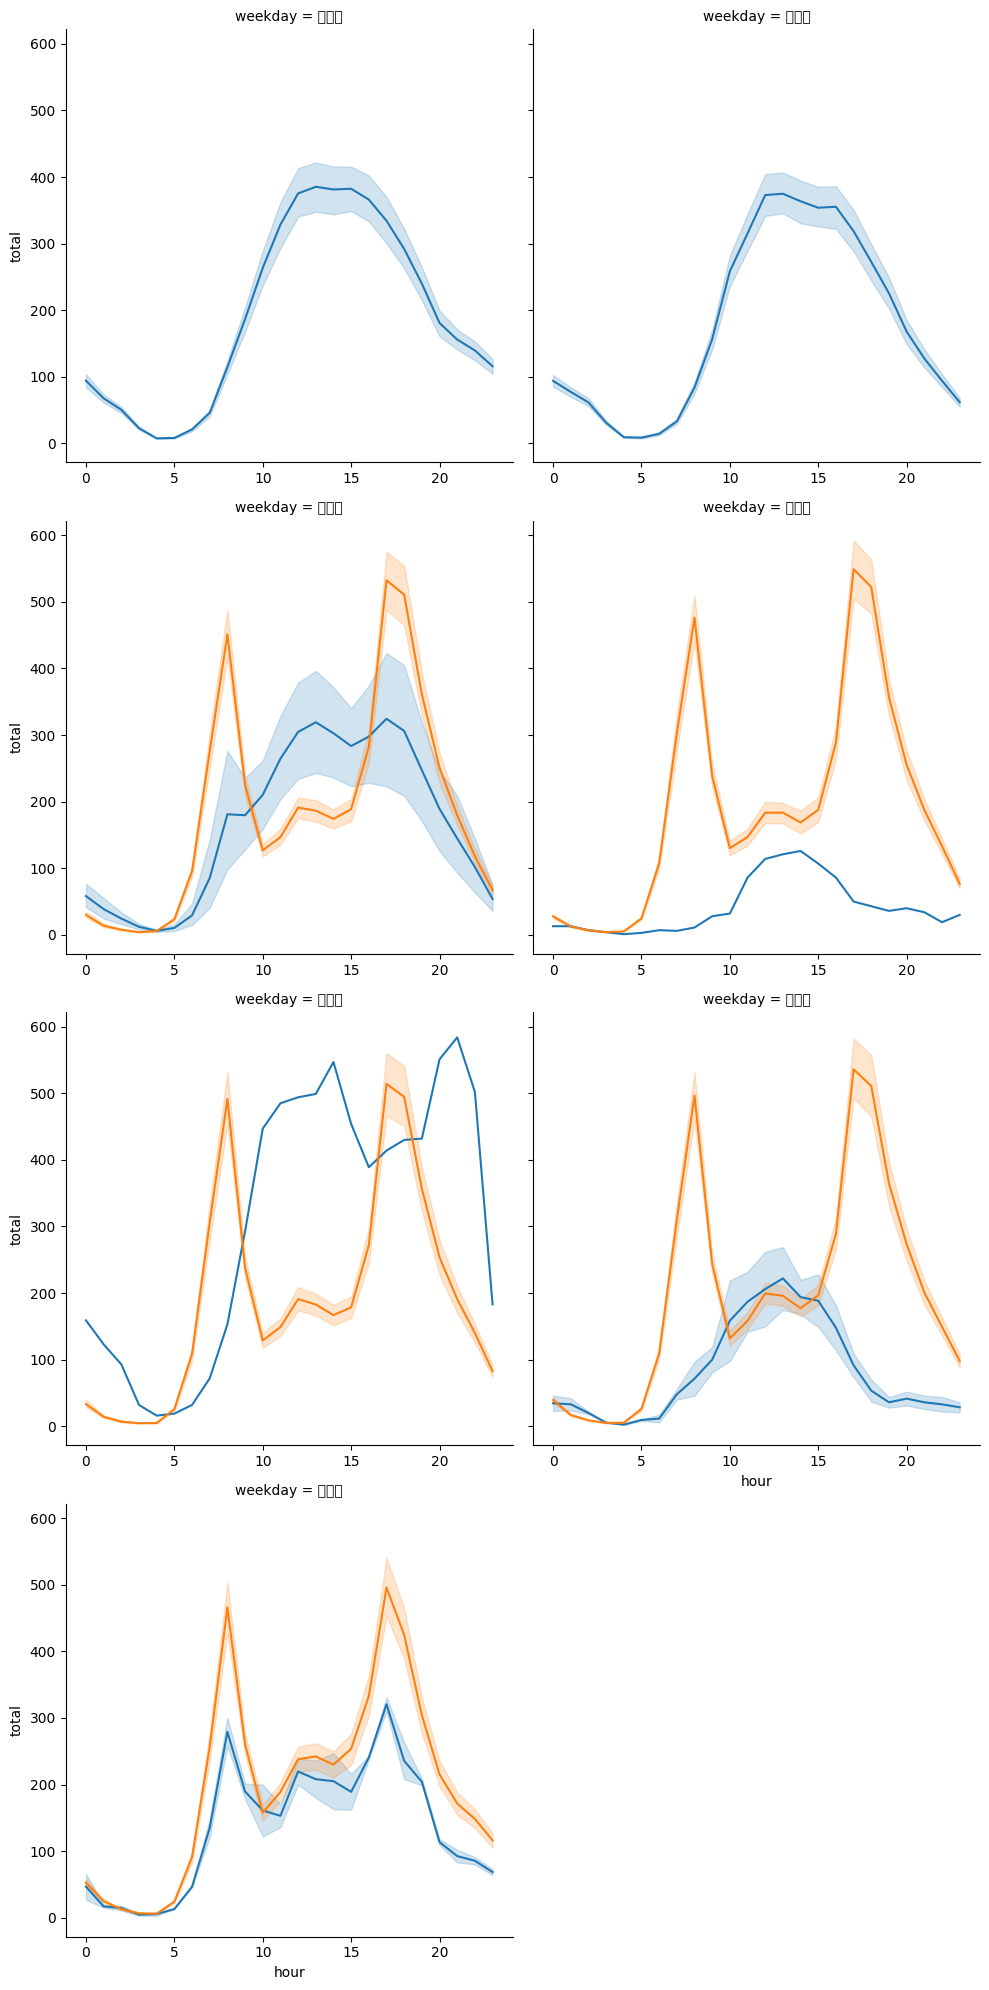

In [28]:
plt.figure(figsize=(30, 10))

mask1 = ((hour_df['workingday'] == 0) | (hour_df['holiday'] == 1))
df1 = hour_df[mask1]
mask2 = ((hour_df['workingday'] == 1) & (hour_df['holiday'] == 0))
df2 = hour_df[mask2]

plot_weekday = sns.FacetGrid(hour_df, col='weekday', hue='workingday', col_wrap=2, height=5, sharex=False)
plot_weekday.map(sns.lineplot, "hour", "total")
plot_weekday.fig.suptitle('自行车租赁数量按工作日和节假日分布', fontsize=20, y=1.02, fontsize=20)
plot_weekday.set_axis_labels('小时', '租赁总数')
plot_weekday.add_legend()

for ax in plot_weekday.axes.flat:
    ax.set(xlabel="小时")
plot_weekday.set_titles(size=10)

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

### 结论

#### 问题1:在什么季节自行车租赁数量最高?
秋季的自行车租赁数量是其他季节中最高的，即在秋季和注册用户中，自行车租租赁数量超过100万。另一方面，春季自行车租赁数量最低，只有471,348。另一方面，在每个季节，登记用户主导自行车租赁的数量。


#### 问题2:租自行车的模式是怎样的?
2012年自行车租金比2011年高。此外，自行车租赁模式在年初至第三季度有所增加，然后在年底有所下降。

#### 问题3:租自行车的时间有什么规律? 
在工作日，自行车租赁在某些时间是很高的，比如5点到8点，15点到17点。这表明工作时间的流逝与自行车租赁数量的增加有关。此外，在周末，自行车租赁的数量往往在7点到3点之间增加。而在工作日，自行车租赁的数量则异常波动。